# Step 1: Programmatic Data Ingestion & Geographical Mapping

This notebook programmatically extracts the London Underground (Tube) network. The network is modeled in **L-Space topology**:
- **Nodes**: Subway stations
- **Edges**: Direct track links connecting consecutive stations
- **Edge Weight**: Geographical distance in meters (computed via the Haversine formula from station coordinates)

We import the loading logic from our local code package `src/` to keep the notebook clean and modular.

In [1]:
import sys
import os

# Add parent directory to path so we can import src
sys.path.append('..')

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_london_network

## 1. Data Ingestion & Network Statistics

We clean and load the London Underground dataset. The raw coordinates are converted to distances using the Haversine formula to assign physical weights to edges.

In [2]:
G_L, df_stations, df_connections, df_lines = load_london_network()

print(f"London Underground L-Space Network:")
print(f"  Number of stations (Nodes, N): {len(G_L.nodes)}")
print(f"  Number of connections (Edges, M): {len(G_L.edges)}")
print(f"  Density (p): {nx.density(G_L):.6f}")
print(f"  Average Degree <k>: {2.0 * len(G_L.edges) / len(G_L.nodes):.4f}")
print(f"  Is Connected: {nx.is_connected(G_L)}")
print(f"  Topological Diameter (D): {nx.diameter(G_L) if nx.is_connected(G_L) else float('inf')}")
print(f"  Topological Radius (R): {nx.radius(G_L) if nx.is_connected(G_L) else float('inf')}")
print(f"  Transitivity (C_glob): {nx.transitivity(G_L):.4f}")

London Underground L-Space Network:
  Number of stations (Nodes, N): 302
  Number of connections (Edges, M): 349
  Density (p): 0.007679
  Average Degree <k>: 2.3113
  Is Connected: True
  Topological Diameter (D): 38
  Topological Radius (R): 19
  Transitivity (C_glob): 0.0546


## 2. Geographical Visualization of the London Tube Map

We plot the network using the physical station coordinates (longitude, latitude) and color-code the connections according to their official line colors.

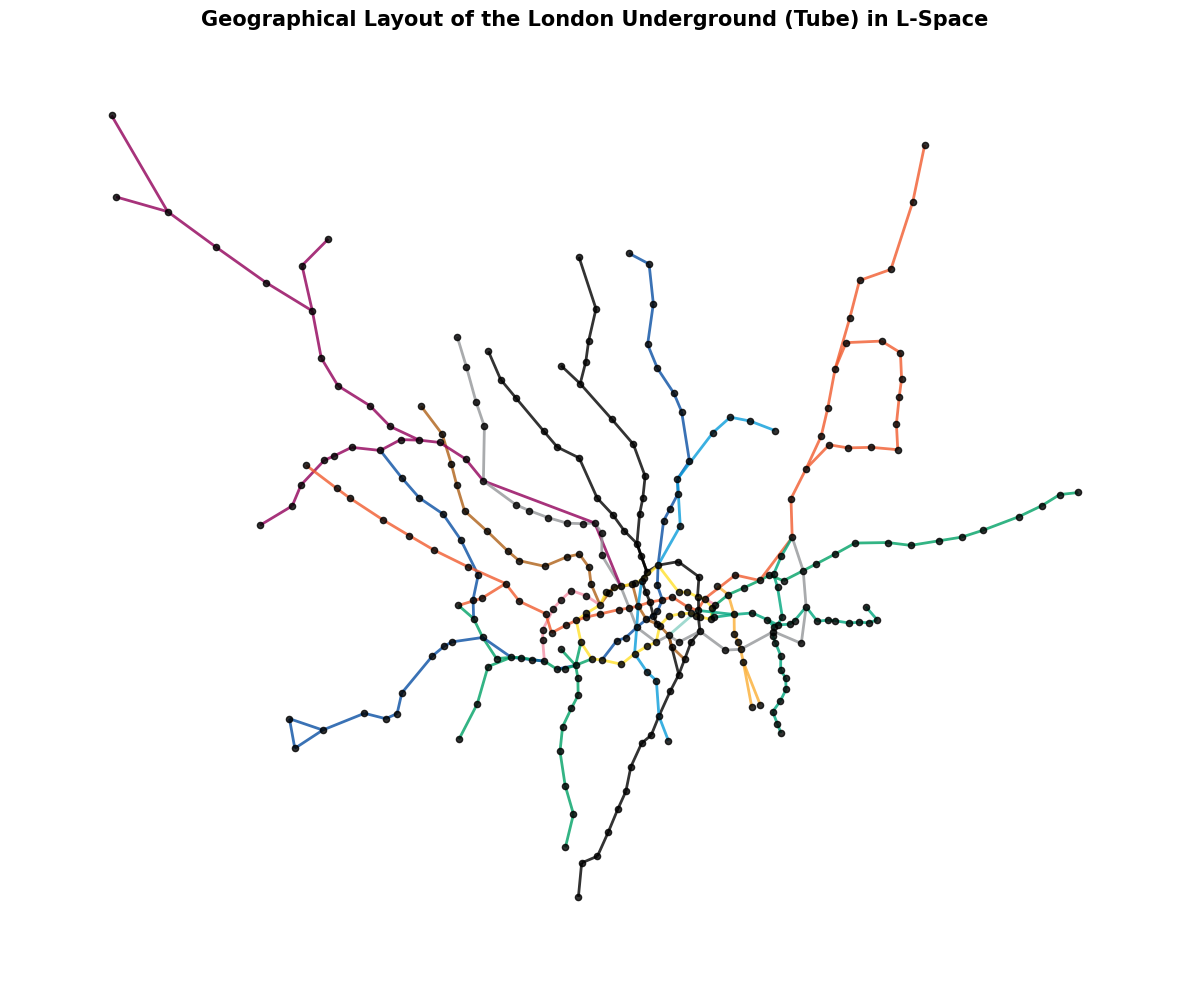

In [3]:
# Color mappings from dataset
line_colors = {int(row['line']): f"#{row['colour']}" for idx, row in df_lines.iterrows()}
pos = {node: (data['lon'], data['lat']) for node, data in G_L.nodes(data=True)}
edge_colors = [line_colors.get(G_L[u][v]['lines'][0], '#999999') for u, v in G_L.edges()]

plt.figure(figsize=(12, 10))
plt.gca().set_facecolor('#fdfefe')

nx.draw_networkx_edges(G_L, pos, edge_color=edge_colors, width=2, alpha=0.8)
nx.draw_networkx_nodes(G_L, pos, node_size=20, node_color='black', alpha=0.8)

plt.title("Geographical Layout of the London Underground (Tube) in L-Space", fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Save figure for report
os.makedirs('../latex/figures', exist_ok=True)
plt.savefig('../latex/figures/london_tube_map.png', dpi=300)
plt.show()

## 3. Network Serialization

We save the built graph to a standardized GraphML file and JSON format in the output folder for potential cross-platform analyses.

In [4]:
os.makedirs('../data_output', exist_ok=True)

# Save as GraphML (strings are used for lists and pos is deleted to ensure compatibility)
G_export = G_L.copy()
for node, data in G_export.nodes(data=True):
    if 'pos' in data:
        del data['pos']
for u, v, data in G_export.edges(data=True):
    data['lines'] = str(data['lines'])
nx.write_graphml(G_export, "../data_output/london_tube.graphml")

print("Graph successfully exported to data_output/london_tube.graphml")

Graph successfully exported to data_output/london_tube.graphml
